In [1]:
from lib.artificial_data import ArtificialTrackDataset, generate_dataset_with_similarities
from lib.user_similarities import calculate_users_track_common_percentage
from lib.plotting import plot_user_similarities_matrix
from lib.matrix_dataset import MatrixDataset
from lib.spoti import NUMERICAL_FEATURES, PRETTY_PRINT_FEATURES
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
SIMPLIFIED_FEATURES = [
    "danceability",
    "duration_ms",
    "instrumentalness",
    "affinity"
]

In [3]:
df_1 = ArtificialTrackDataset(
    default_value=2,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "owen"},
).randomize()

df_2 = ArtificialTrackDataset(
    default_value=3,
    numerical_features=SIMPLIFIED_FEATURES,
    n_samples=5,
    constant_features={"username": "paul"},
).randomize().insert_some_tracks(df_1, 0.5, 0.5)[0].randomize(["affinity"]).shuffle()

df = df_1.merge(df_2)

display(df.data)

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Matter safe,owen,0.875786,0.951341,0.974450,0.902828
1,Data too,owen,1.061079,0.898552,0.989533,0.960004
2,Development,owen,0.941317,1.127113,0.969077,0.906339
3,Majority never,owen,0.943344,1.017453,1.051808,0.943671
4,Effort eight,owen,1.002586,0.950095,1.042582,1.038524
5,Reach common,paul,1.112512,1.124024,1.168957,1.004698
6,Across yet,paul,1.053293,0.983089,0.916252,1.120559
7,Data too,paul,1.061079,0.898552,0.989533,1.024912
8,Could present,paul,1.127446,0.937392,0.991916,0.865861
9,Majority never,paul,0.943344,1.017453,1.051808,1.127874


In [4]:
df = generate_dataset_with_similarities(
    num_users=500,
    n_samples=150,
    numerical_features=SIMPLIFIED_FEATURES,
    affinity_feature="affinity",
    max_track_mixing_percentage=0.8,
    min_track_mixing_percentage=0.9,
    mix_with_someone_else_chance=0.8,
)
df.data

Mixing user Micheal Woods with Stephen Smith with a replacement percentage of 87.33%
Mixing user Lynn Butler with David Knox with a replacement percentage of 84.67%
Mixing user Amanda Perry with Wendy Bryan with a replacement percentage of 80.00%
Mixing user Melissa Hernandez with Alexis Campbell with a replacement percentage of 83.33%
Mixing user Dennis Taylor with Thomas Cabrera with a replacement percentage of 82.67%
Mixing user Christina Roberts with Donald Henderson with a replacement percentage of 86.67%
Mixing user Michelle Contreras with Harry Lucero with a replacement percentage of 82.00%
Mixing user Lee Hall with Jack Brown with a replacement percentage of 86.00%
Mixing user Sandra Martin with Karen Martinez with a replacement percentage of 84.67%
Mixing user Zachary Smith with Katherine Blanchard with a replacement percentage of 88.67%
Mixing user Dr. April Garrison with Amanda Castaneda with a replacement percentage of 88.00%
Mixing user Joshua Padilla with Karla Mason with

,id,username,danceability,duration_ms,instrumentalness,affinity
0,Believe,Micheal Woods,0.832951,1.041581,1.029700,0.873513
1,Executive,Micheal Woods,0.779545,0.793655,0.987299,0.970585
2,This fall,Micheal Woods,0.900645,1.194748,0.928675,0.988203
3,Care hair,Micheal Woods,0.974839,0.933725,0.980782,0.923037
4,Computer blood,Micheal Woods,1.091138,1.163467,0.998281,0.937892
...,...,...,...,...,...,...
74995,Democrat past,Dave Pitts,0.948012,0.959504,0.902671,0.851102
74996,Defense,Dave Pitts,0.801451,1.048954,0.972620,1.043628
74997,Drug she head,Dave Pitts,1.085254,1.189520,1.030366,1.159210
74998,Behind major,Dave Pitts,0.951674,1.081677,1.107865,1.004385


In [5]:
df.data.to_csv("data/artificial_data_df.csv")

In [6]:
df_track_common = calculate_users_track_common_percentage(df.data, username_col="username", trackname_col="id")
df_track_common

username,Aaron Green,Aaron Villarreal,Adam Sellers MD,Alec Davis,Alexa Tran,Alexander Bishop,Alexis Campbell,Alexis Guerra,Allison Green,Allison Turner,...,Walter Gentry,Wendy Bryan,Wendy Nguyen,Wendy Sullivan,Wesley Smith,William Lowe,Yvette White,Zachary Mendez,Zachary Smith,Zachary Williams
username,,,,,,,,,,,,,,,,,,,,,
Aaron Green,1.000000,0.026667,0.026667,0.013333,0.013333,0.093333,0.013333,0.006667,0.006667,0.013333,...,0.006667,0.020000,0.033333,0.020000,0.020000,0.020000,0.006667,0.013333,0.013333,0.006667
Aaron Villarreal,0.026667,1.026667,0.026667,0.033333,0.053333,0.033333,0.020000,0.026667,0.006667,0.046667,...,0.026667,0.013333,0.046667,0.040000,0.033333,0.046667,0.006667,0.020000,0.046667,0.026667
Adam Sellers MD,0.026667,0.026667,1.013333,0.026667,0.026667,0.013333,0.006667,0.006667,0.020000,0.033333,...,0.006667,0.020000,0.033333,0.033333,0.033333,0.020000,0.006667,0.013333,0.000000,0.013333
Alec Davis,0.013333,0.033333,0.026667,1.026667,0.013333,0.040000,0.026667,0.013333,0.026667,0.006667,...,0.033333,0.026667,0.006667,0.053333,0.013333,0.013333,0.020000,0.013333,0.026667,0.013333
Alexa Tran,0.013333,0.053333,0.026667,0.013333,1.026667,0.013333,0.020000,0.013333,0.013333,0.013333,...,0.026667,0.000000,0.026667,0.020000,0.006667,0.006667,0.020000,0.006667,0.020000,0.013333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
William Lowe,0.020000,0.046667,0.020000,0.013333,0.006667,0.033333,0.013333,0.013333,0.033333,0.040000,...,0.026667,0.000000,0.026667,0.006667,0.020000,1.026667,0.006667,0.026667,0.013333,0.006667
Yvette White,0.006667,0.006667,0.006667,0.020000,0.020000,0.013333,0.013333,0.013333,0.013333,0.006667,...,0.013333,0.020000,0.013333,0.006667,0.013333,0.006667,1.013333,0.013333,0.006667,0.013333
Zachary Mendez,0.013333,0.020000,0.013333,0.013333,0.006667,0.026667,0.013333,0.013333,0.020000,0.013333,...,0.013333,0.006667,0.000000,0.020000,0.040000,0.026667,0.013333,1.000000,0.013333,0.006667


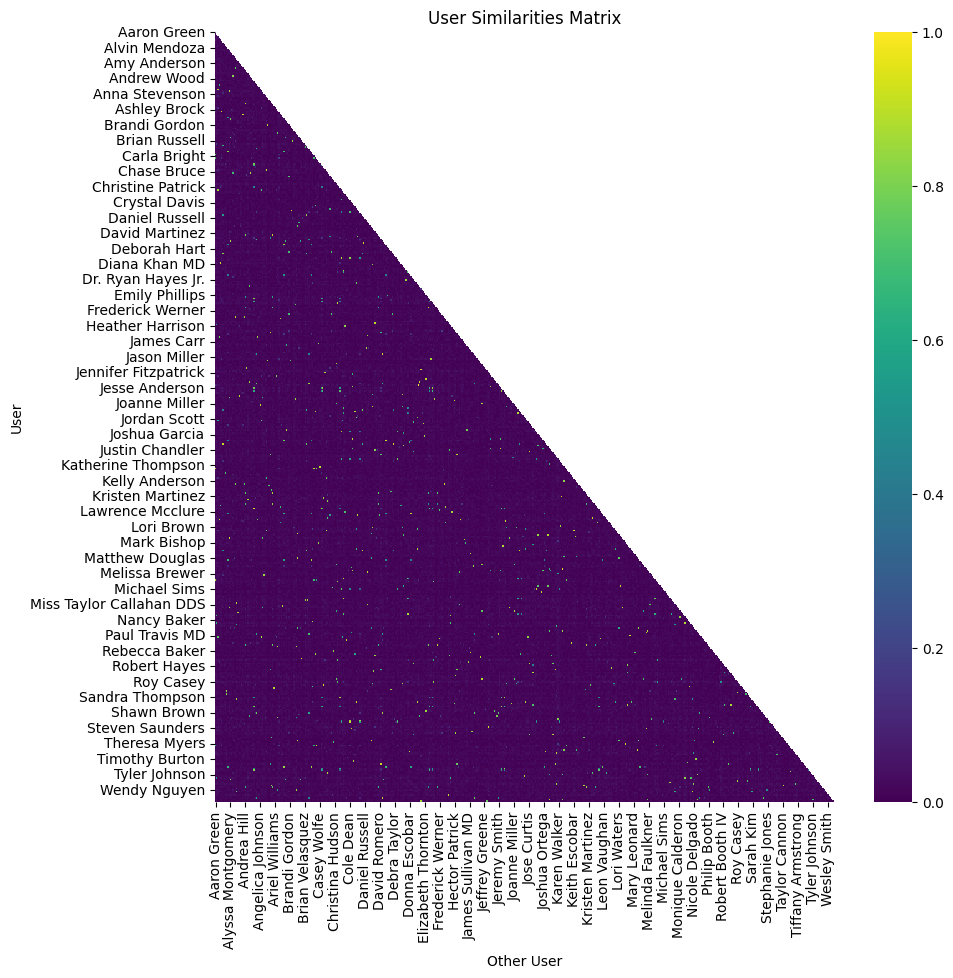

In [7]:
plot_user_similarities_matrix(df_track_common, figsize=(10, 10))

In [8]:
df.data.to_csv(os.path.join("data", "artificial_data.csv"))

In [9]:
M = MatrixDataset(df.data, user_col="username", item_col="id", value_col="affinity")
M.R.shape

torch.Size([498, 30531])